In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# Figuras vectoriales
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# Crear dos matrices aleatorias normales
q = np.random.randn(50, 50) # q,ddof=1 sutileza estadistica de np
k = np.random.randn(50, 50)

# Todos los productos punto por pares mediante multiplicación de matrices
dp = q @ k.T

In [3]:
# Comprobar las medias y desviaciones estándar
std_q = np.std(q)
std_k = np.std(k)
std_dp = np.std(dp)

print(f'Desviación estándar de q:     {std_q:.4f}')
print(f'Desviación estándar de k:     {std_k:.4f}')
print(f'Desviación estándar de dp:    {std_dp:.4f}')
print(f'Raíz cuadrada de la dimensión: {np.sqrt(q.shape[1]):.4f}')

Desviación estándar de q:     0.9943
Desviación estándar de k:     1.0044
Desviación estándar de dp:    7.0236
Raíz cuadrada de la dimensión: 7.0711


Esto quiere decir que la desviacion estandar no es exacta pero extremadamente cercana a la raiz cuadrada de la dimensión

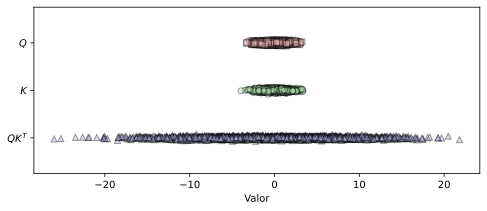

In [4]:
plt.figure(figsize=(8, 3))

q_flat = q.flatten()
k_flat = k.flatten()
dp_flat = dp.flatten()
n = len(q_flat)

plt.plot(q_flat, np.random.normal(2, 0.02, n), 'ks', markerfacecolor=[0.9, 0.7, 0.7], alpha=0.4)
plt.plot(k_flat, np.random.normal(1, 0.02, n), 'ko', markerfacecolor=[0.7, 0.9, 0.7], alpha=0.4)
plt.plot(dp_flat, np.random.normal(0, 0.02, n), 'k^', markerfacecolor=[0.7, 0.7, 0.9], alpha=0.4)

plt.gca().set(
    yticks=[0, 1, 2],
    yticklabels=['$QK^T$', '$K$', '$Q$'],
    ylim=[-0.75, 2.75],
    xlabel='Valor'
)
plt.show()

### Análisis de la dispersión en el producto punto ($QK^T$)

* **Distribución base de $Q$ y $K$:** Ambas matrices provienen de una distribución normal estándar ($\mu = 0$, $\sigma \approx 1$). Por ello, sus valores se mantienen compactos en un rango estrecho, aproximadamente entre $[-3, 3]$.
* **Explosión de la varianza en $QK^T$:** Cada elemento del producto matricial $QK^T$ es la suma de $d = 50$ multiplicaciones de variables aleatorias independientes:

$$\text{Var}(q \cdot k) = d \cdot \sigma_q^2 \sigma_k^2 = 50 \implies \sigma_{QK^T} \approx \sqrt{50} \approx 7.07$$



Esto provoca que la dispersión se multiplique por un factor de $\sqrt{d}$, extendiendo los valores a un rango mucho más amplio (aproximadamente entre $[-30, 35]$).
* **Justificación del factor de escala ($\sqrt{d_k}$) en Transformers:** Este gráfico ilustra directamente por qué el mecanismo de atención (*Scaled Dot-Product Attention*) divide entre $\sqrt{d_k}$. Si estos valores de magnitud elevada entraran directamente a una función $\text{Softmax}$, saturarían las probabilidades hacia los extremos (0 y 1), provocando el problema de desvanecimiento de gradientes (*vanishing gradients*) durante el entrenamiento. Al dividir entre $\sqrt{d_k}$, la varianza se restablece a 1.

## Mulriplicando Matrices

In [5]:
vector_lengths = np.arange(2, 100)

dp_stds = np.zeros(len(vector_lengths))

for l in range(len(vector_lengths)):

  # Crear dos matrices
  q = np.random.randn(50, vector_lengths[l])
  k = np.random.randn(50, vector_lengths[l])

  # Sus productos punto
  dps = q @ k.T

  # Su desviación estándar
  dp_stds[l] = np.std(dps)

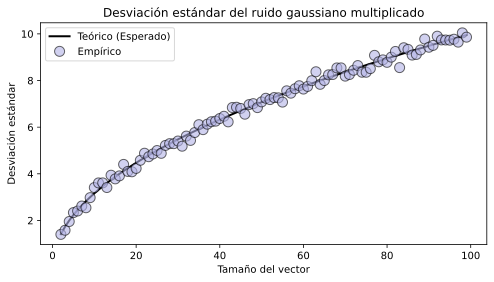

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(vector_lengths, np.sqrt(vector_lengths), 'k', linewidth=2, label='Teórico (Esperado)')
plt.plot(vector_lengths, dp_stds, 'ko', markersize=10, markerfacecolor=[0.7, 0.7, 0.9], alpha=0.6, label='Empírico')

plt.legend()
plt.gca().set(
    xlabel='Tamaño del vector',
    ylabel='Desviación estándar',
    title='Desviación estándar del ruido gaussiano multiplicado'
)
plt.show()

### Análisis de la relación entre dimensión y variabilidad del producto punto

* **Ajuste empírico-teórico perfecto:** La curva continua representa la función teórica $\sqrt{d}$ (donde $d$ es la longitud del vector/dimensión del embedding), y los círculos representan la desviación estándar calculada numéricamente de $q \cdot k^T$. El alineamiento es casi exacto a lo largo de todo el rango evaluado ($2$ a $100$).
* **Crecimiento no lineal sublineal:** La desviación estándar del producto punto no escala de forma lineal con la dimensión, sino con la raíz cuadrada de esta:

$$\sigma_{q \cdot k} = \sqrt{\sum_{i=1}^{d} \text{Var}(q_i k_i)} = \sqrt{d \cdot (1 \cdot 1)} = \sqrt{d}$$



Para vectores de tamaño 4 la dispersión es ~2; para tamaño 25 es ~5; y para tamaño 100 alcanza ~10.
* **Confirmación matemática del escalado en la atención:** Esta demostración numérica justifica formalmente el denominador de la atención de Vaswani et al. (*Scaled Dot-Product Attention*):

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$



Dividir por $\sqrt{d_k}$ no es una constante heurística arbitraria, sino el factor de normalización exacto necesario para contrarrestar este crecimiento y mantener la varianza en $1$, evitando que la Softmax se sature hacia un comportamiento de tipo "one-hot" (desvaneciendo gradientes).

In [7]:
# Mientras mas largas sean las mulriplicaciones de matrices mas largas seran las desviaciones estandar de sus productos punto

In [11]:
vector_lengths = np.arange(2, 100)

dp_stds = np.zeros(len(vector_lengths))

for l in range(len(vector_lengths)):

  # Crear dos matrices
  q = np.random.randn(50, vector_lengths[l])
  k = np.random.randn(50, vector_lengths[l])

  # Sus productos punto
  dps = q @ k.T

  # Su desviación estándar
  dp_stds[l] = np.std(q) + np.std(k)

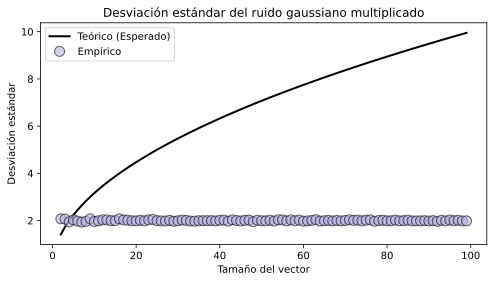

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(vector_lengths, np.sqrt(vector_lengths), 'k', linewidth=2, label='Teórico (Esperado)')
plt.plot(vector_lengths, dp_stds, 'ko', markersize=10, markerfacecolor=[0.7, 0.7, 0.9], alpha=0.6, label='Empírico')

plt.legend()
plt.gca().set(
    xlabel='Tamaño del vector',
    ylabel='Desviación estándar',
    title='Desviación estándar del ruido gaussiano multiplicado'
)
plt.show()

```python
dp_stds[l] = np.std(q) + np.std(k)

```

---

### Análisis del gráfico

* **Comportamiento empírico constante (~2.0):** Como las matrices $q$ y $k$ se muestrean de una distribución normal estándar $\mathcal{N}(0, 1)$, la desviación estándar de cada una es aproximadamente $1.0$, independientemente de cuántas columnas tengan (`vector_lengths`). Por ende, su suma es fija:

$$\text{std}(q) + \text{std}(k) \approx 1.0 + 1.0 = 2.0$$


* **Desacople con la curva teórica:** La curva negra continua representa $\sqrt{d}$ (el comportamiento del **producto punto** $q \cdot k^T$). Al sumar las desviaciones estándar individuales en lugar de calcular la del producto punto, los puntos empíricos quedan en una línea horizontal plana en torno a $2.0$, demostrando que la suma de dispersiones no depende de la dimensión del vector, a diferencia del producto matricial que sí crece con $\sqrt{d}$.

## Implicaciones de Softmax

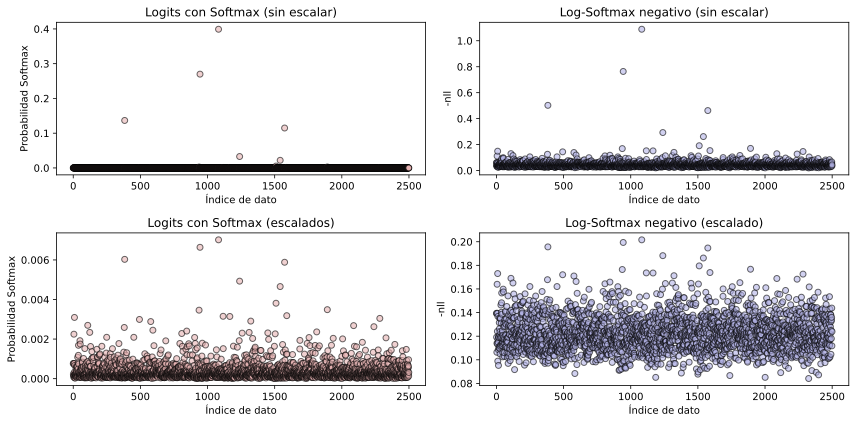

In [13]:
# Crear dos matrices/vectores
q = np.random.randn(50, 50)
k = np.random.randn(50, 50)

# Su producto punto
dps = q @ k.T

_, axs = plt.subplots(2, 2, figsize=(12, 6))
for i in range(2):

  # Posible escalado
  if i == 1:
    dps /= np.sqrt(q.shape[1])

  # Calcular softmax y nll
  dps_flat = dps.flatten()
  softmax = np.exp(dps_flat) / np.sum(np.exp(dps_flat))
  nll = -1 / np.log(softmax)

  # Y graficar
  axs[i, 0].plot(softmax, 'ko', markerfacecolor=[0.9, 0.7, 0.7], alpha=0.6)
  axs[i, 0].set(
      xlabel='Índice de dato',
      ylabel='Probabilidad Softmax',
      title='Logits con Softmax (' + ['sin escalar', 'escalados'][i] + ')'
  )

  axs[i, 1].plot(nll, 'ko', markerfacecolor=[0.7, 0.7, 0.9], alpha=0.6)
  axs[i, 1].set(
      xlabel='Índice de dato',
      ylabel='-nll',
      title='Log-Softmax negativo (' + ['sin escalar', 'escalado'][i] + ')'
  )

plt.tight_layout()
plt.show()

In [15]:
# En la 1 muy pocas probabilidades de seleccionar los tokens en la 2 -mayor variabilidad - en la Log-softmax negativa mayor probabilidad

### Análisis de la comparación: Sin escalar vs. Escalados

* **Fila superior (Sin escalar — $QK^T$ puro):**
* **Saturación en Softmax:** Al tener valores con varianza elevada ($\sigma \approx 7.07$), la función exponencial de Softmax magnifica exponencialmente las diferencias. Unos pocos elementos dominan de forma aplastante (alcanzando probabilidades de hasta $0.40$ o $0.27$), mientras que los demás 2,490+ tokens quedan prácticamente aplastados en probabilidad $0.0$.
* **Comportamiento cuasi-determinista (*hardmax*):** El modelo concentra toda su atención de manera artificial en 3 o 4 posiciones debido únicamente a fluctuaciones aleatorias del producto punto.
* **Problema de gradientes:** En las zonas donde Softmax vale $0$ o saturó hacia $1$, la derivada de Softmax $\left(\frac{\partial \text{Softmax}_i}{\partial z_j} = s_i(\delta_{ij} - s_j)\right)$ tiende a $0$, provocando el desvanecimiento de gradientes (*vanishing gradient*) que paraliza el entrenamiento.


* **Fila inferior (Escalados — $\frac{QK^T}{\sqrt{d_k}}$):**
* **Distribución probabilística equilibrada:** Al dividir entre $\sqrt{50} \approx 7.07$, la varianza de los logits vuelve a $1.0$. La probabilidad máxima en Softmax cae de $0.40$ a un rango mucho más realista y saludable de $0.006$ (para 2,500 elementos, la probabilidad uniforme teórica sería $\frac{1}{2500} = 0.0004$).
* **Entropía adecuada:** La masa de probabilidad se reparte de forma suave entre todas las claves candidatas, permitiendo que el mecanismo de atención pondere el contexto completo en lugar de fijarse ciegamente en un solo elemento aleatorio.
* **Gradientes estables:** Los valores de log-softmax negativo (columna derecha) quedan bien acotados en una banda uniforme ($0.08$ a $0.20$), garantizando un flujo de gradientes fluido y dinámico hacia todas las capas anteriores de la red.

In [16]:
# Importante

* **En un modelo inicial / aleatorio (Pre-entrenamiento o pesos al azar):**
* **No queremos variabilidad extrema (valores muy grandes):** Si la variabilidad es enorme, la Softmax se polariza de inmediato (unos pocos tokens se llevan el 99% de la probabilidad y el resto 0%). El modelo se vuelve "terco" y seguro de predicciones puramente aleatorias, aplastando los gradientes a cero y bloqueando el aprendizaje.
* **Tampoco queremos variabilidad nula (valores demasiado pequeños):** Si todos los logits son idénticos, la distribución queda 100% plana/uniforme y el modelo no tiene ninguna señal direccional para priorizar nada.
* **El punto óptimo:** Dividir por $\sqrt{d_k}$ preserva una varianza equilibrada ($\sigma \approx 1$), permitiendo que el modelo explore todo el contexto y reciba gradientes sanos en todas las posiciones.


* **En Fine-tuning (Alineación / Adaptación):**
* **La baja variabilidad / control estricto es deseable:** Aquí el objetivo ya no es aprender representaciones desde cero, sino **restringir o especializar** el comportamiento (por ejemplo, forzar un tono servicial, alineación con RLHF o el ejercicio de obligar a emitir únicamente tokens con "x").
* **Control determinista:** Interesa concentrar la masa de probabilidad exclusivamente en el subconjunto de tokens deseados sin que el modelo divague en opciones no autorizadas o irrelevantes para la tarea.

Estamos agarrando todos los parametros de layernorm y weights y el bias

In [17]:
from transformers import AutoModelForCausalLM, GPT2Tokenizer
gpt2 = AutoModelForCausalLM.from_pretrained('gpt2')

# Reunir todos los parámetros de layernorm en vectores
all_ln_weights = np.array([])
all_ln_biases = np.array([])

for name, mat in gpt2.named_parameters():
  if 'ln' in name:
    if 'weight' in name:
      all_ln_weights = np.append(all_ln_weights, mat.data)
    elif 'bias' in name:
      all_ln_biases = np.append(all_ln_biases, mat.data)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

/tmp/ipykernel_3681/370249402.py:7: RuntimeWarning: divide by zero encountered in log
  axs[0].plot(xW[:-1], np.log(yW), 'ks-', markerfacecolor=[0.9, 0.7, 0.7])
/tmp/ipykernel_3681/370249402.py:14: RuntimeWarning: divide by zero encountered in log
  axs[1].plot(xB[:-1], np.log(yB), 'ko-', markerfacecolor=[0.7, 0.7, 0.9])


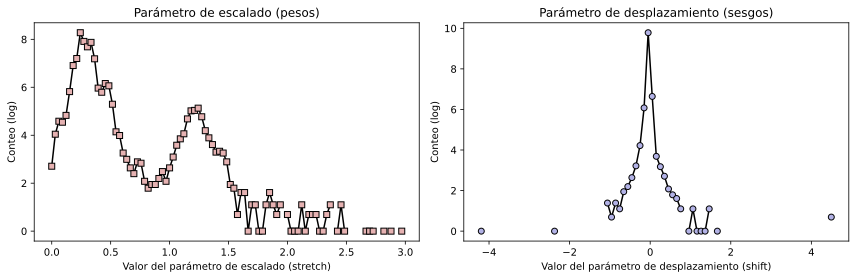

In [18]:
# Calcular sus distribuciones
yW, xW = np.histogram(all_ln_weights, bins=np.linspace(0, 3, 100))
yB, xB = np.histogram(all_ln_biases, bins=np.linspace(-5, 5, 100))

# Y graficar
_, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(xW[:-1], np.log(yW), 'ks-', markerfacecolor=[0.9, 0.7, 0.7])
axs[0].set(
    xlabel='Valor del parámetro de escalado (stretch)',
    ylabel='Conteo (log)',
    title='Parámetro de escalado (pesos)'
)

axs[1].plot(xB[:-1], np.log(yB), 'ko-', markerfacecolor=[0.7, 0.7, 0.9])
axs[1].set(
    xlabel='Valor del parámetro de desplazamiento (shift)',
    ylabel='Conteo (log)',
    title='Parámetro de desplazamiento (sesgos)'
)

plt.tight_layout()
plt.show()

### Análisis de los parámetros aprendidos en LayerNorm (GPT-2)

La normalización por capas (*LayerNorm*) estandariza las activaciones a media $0$ y varianza $1$, para luego aplicar dos parámetros entrenables por dimensión:


$$\text{LN}(x) = \gamma \odot \left(\frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}\right) + \beta$$


donde **$\gamma$** es el peso de escalado (*stretch*) y **$\beta$** es el sesgo de desplazamiento (*shift*). Al inicio del entrenamiento, se inicializan de forma neutra: $\gamma = 1$ y $\beta = 0$.

---

#### 1. Parámetro de escalado $\gamma$ (Gráfico izquierdo)

* **Comportamiento bimodal:** Se observan dos cúspides claras: una alrededor de $\approx 0.25$ y otra menor cerca de $\approx 1.25$. Esto indica que el modelo aprende dos estrategias principales: comprimir deliberadamente la variabilidad de ciertas características hacia valores más estables ($\gamma < 1$) y amplificar suavemente otras señales relevantes ($\gamma > 1$).
* **El efecto de la escala logarítmica:** En el gráfico, la segunda joroba parece casi del mismo tamaño que la primera porque el eje vertical está en escala logarítmica ($\ln(\text{conteo})$).
* El primer pico alcanza un valor logarítmico de $\approx 8.3 \implies e^{8.3} \approx 4,000$ parámetros.
* El segundo pico alcanza un valor logarítmico de $\approx 5.0 \implies e^{5.0} \approx 150$ parámetros.
* **Si le quitamos el $\log$:** La segunda joroba se reduce a una pequeña protuberancia. La inmensa mayoría de las dimensiones aprendidas se concentran en el rango bajo ($0.2$ a $0.4$). El salto visual entre ambas no refleja una distribución equitativa, sino una diferencia de más de un orden de magnitud en cantidad real de parámetros.



---

#### 2. Parámetro de desplazamiento $\beta$ (Gráfico derecho)

* **Alta simetría centrada en cero:** La distribución tiene un pico afilado exactamente en $0.0$, lo que confirma que la mayoría de los canales mantienen la media centrada sin necesidad de aplicar un desplazamiento constante.
* **Estabilidad sin derivas extremas:** Prácticamente todos los sesgos se ubican en la franja $[-1, 1]$. Salvo un par de valores atípicos aislados (cerca de $-4$ y $+4.5$), el modelo preserva la condición de media cercana a cero que provee la normalización base.

---

> **Nota técnica sobre los *warnings*:** Las alertas `RuntimeWarning: divide by zero encountered in log` ocurren porque en los bins donde el conteo de parámetros es $0$, NumPy evalúa $\ln(0) = -\infty$. Si se grafican los conteos lineales directos (`yW` y `yB` sin `np.log`), desaparecen las advertencias y se visualiza la proporción real sin la compresión visual del logaritmo.

/tmp/ipykernel_3681/1457190510.py:14: RuntimeWarning: divide by zero encountered in log
  axs[1].plot(xB[:-1], np.log(yB), 'ko-', markerfacecolor=[0.7, 0.7, 0.9])


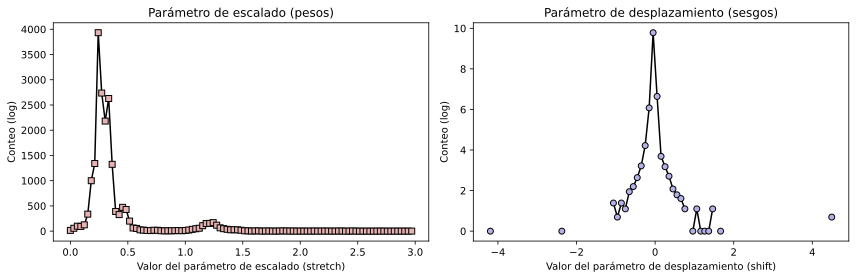

In [19]:
# Calcular sus distribuciones
yW, xW = np.histogram(all_ln_weights, bins=np.linspace(0, 3, 100))
yB, xB = np.histogram(all_ln_biases, bins=np.linspace(-5, 5, 100))

# Y graficar
_, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(xW[:-1],(yW), 'ks-', markerfacecolor=[0.9, 0.7, 0.7])
axs[0].set(
    xlabel='Valor del parámetro de escalado (stretch)',
    ylabel='Conteo (log)',
    title='Parámetro de escalado (pesos)'
)

axs[1].plot(xB[:-1], np.log(yB), 'ko-', markerfacecolor=[0.7, 0.7, 0.9])
axs[1].set(
    xlabel='Valor del parámetro de desplazamiento (shift)',
    ylabel='Conteo (log)',
    title='Parámetro de desplazamiento (sesgos)'
)

plt.tight_layout()
plt.show()

In [20]:
# Ese rebote realmente es muy minimo

Matemáticamente, la multiplicación de matrices aumenta la varianza y el rango numérico de los valores; es una característica inherente al álgebra lineal y tiene sentido (por ejemplo, 2 × 3 es 6, y 6 es mayor que 2 y 3). Permitir que estos números crezcan descontroladamente produce graves consecuencias en la estabilidad numérica y también afecta la función Softmax sobre los logits al realizar la selección probabilística de tokens. Por esta razón, se aplican múltiples normalizaciones en casi todos los pasos de la arquitectura.